In [3]:
import os
import time
import shutil
import torch
import matplotlib.pyplot as plt
import importlib

import generate
importlib.reload(generate)

from generate import ShapeGenerator

shapes = {
    "circle": {"shape": "circle", "num_points": 60, "percentage": 0.30},
    "hexagon": {"shape": "hexagon", "num_points": 60, "percentage": 0.25},
    "triangle": {"shape": "triangle", "num_points": 60, "percentage": 0.20},
    "star_5": {"shape": "star", "num_points": 60, "n_tips": 5, "inner_radius": 0.45, "percentage": 0.15},
    "star_12": {"shape": "star", "num_points": 2500, "n_tips": 12, "inner_radius": 0.6, "percentage": 0.10},
}

transform_cfg = {
    "translation_range": [-1.0, 1.0],
    "scale_range": [0.2, 2.0],
    "rotation_range": [0.0, 360.0],
}

shape_generator = ShapeGenerator()
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

Using device: cpu


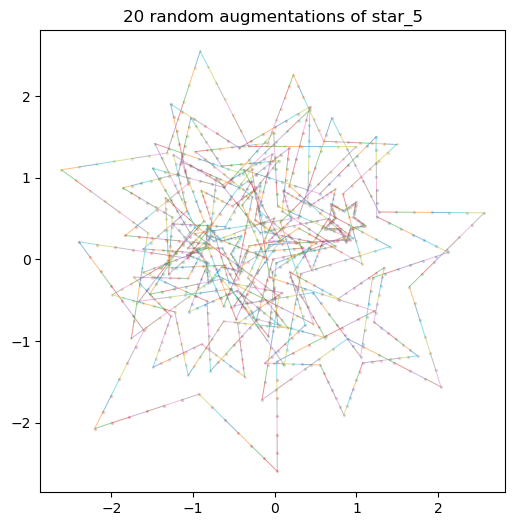

In [8]:
shape_name = "star_5"
num_aug = 20

batch = shape_generator.generate_batch_torch(
    instance_name=shape_name,
    shape_spec=shapes[shape_name],
    transform_cfg=transform_cfg,
    batch_size=num_aug,
    seed=123,
    device=device,
    return_points=True,
)

points = batch["points"].detach().cpu().numpy()   # [B, P, 2]
edges = batch["edges"].detach().cpu().numpy()     # [E, 2]

plt.figure(figsize=(6, 6))

for i in range(num_aug):
    p = points[i]

    for e in edges:
        plt.plot(
            p[e, 0],
            p[e, 1],
            alpha=0.5,
            linewidth=0.7,
        )

    plt.scatter(
        p[:, 0],
        p[:, 1],
        s=2,
        alpha=0.2,
    )

plt.axis("equal")
plt.title(f"{num_aug} random augmentations of {shape_name}")
plt.show()